# Whitened Innovation CUSUM for Drift-Triggered Online Adaptation

**Purpose.** Summarize what we did over the last two days: replacing hard-coded/manual drift triggers with a covariance-aware whitened innovation CUSUM trigger in the SubspaceNet+EKF online-learning pipeline.

**Main result.** The trigger detects drift effectively in N=20 validation, but the current calibration still has 2/20 no-drift false alarms, so it is not yet a final paper configuration.

**PPT takeaway.** The contribution is a statistically interpretable trigger design and validation workflow, not a claim that the current setting already beats every manual baseline.

## 1. What were we trying to do?

The starting point was a SubspaceNet+EKF online adaptation pipeline for DoA estimation under array-response drift.

Before this task, the repository already had:

| Component | Status |
| --- | --- |
| SubspaceNet DoA estimator | Implemented. |
| EKF downstream tracker | Implemented and already outputs innovation-related quantities. |
| Online adaptation with pseudo-labels | Implemented. |
| Automatic drift trigger | Not fully solved; online learning was still mainly controlled by `time_to_learn`. |

The task was to turn innovation statistics into a real drift trigger:

```text
X_i -> SubspaceNet g_psi(X_i) -> EKF tracker -> innovation y_i
                                      |
                                      +-> drift detection
                                      +-> unsupervised adaptation
```

**PPT takeaway.** The pipeline had the estimator, tracker, and online-learning machinery; the missing piece was a statistically grounded automatic trigger.

## 2. Why manual thresholding is not enough

The original trigger idea monitors a sliding-window innovation energy:

$$
\sigma_y^2(i)=\frac{1}{I}\sum_{j=i-I+1}^{i}\|y_j\|^2
$$

and starts online adaptation when:

$$
\sigma_y^2(i) > \tau_\sigma.
$$

This has three practical problems:

1. **Manual tuning.** `tau_sigma` is a hand-set threshold.
2. **Scale sensitivity.** Raw innovation magnitude depends on EKF uncertainty, measurement noise, SNR, snapshot count, and checkpoint quality.
3. **Weak transferability.** A threshold that works for one drift/noise/checkpoint setting may not be meaningful in another deployment.

**PPT takeaway.** Manual `tau_sigma` can work as an engineering baseline, but it does not provide a portable false-alarm interpretation.

## 3. Core idea: whiten the innovation

The EKF already computes an innovation covariance:

$$
S_i = P_{i|i-1} + R_{obs}.
$$

Instead of thresholding raw innovation energy, we normalize the innovation by this covariance:

$$
c_i = y_i^T S_i^{-1}y_i.
$$

If the no-drift model is well calibrated, this statistic should behave like a chi-square statistic with `M=3` degrees of freedom:

$$
c_i \approx \chi^2(3) \quad \text{under no drift}.
$$

This changes the detection problem from:

```text
How large is the raw residual?
```

to:

```text
How surprising is the residual relative to the EKF uncertainty?
```

**PPT takeaway.** Whitening makes the trigger covariance-aware; the same residual is treated differently when the tracker is uncertain versus confident.

## 4. From statistic to trigger: Page-CUSUM

A single large residual can be noisy, so the trigger accumulates persistent evidence:

$$
G_i = \max(0, G_{i-1} + c_i - b).
$$

Online adaptation starts when:

$$
G_i > h.
$$

In this implementation:

| Quantity | Meaning |
| --- | --- |
| `c_i` | whitened innovation statistic |
| `b` | reference value; implemented through `b_offset` |
| `h` | CUSUM threshold derived from target `p_fa` |
| `reset_after_trigger` | resets the accumulator after a trigger |

Final validated candidate:

```yaml
kalman_filter:
  measurement_noise_std_dev: 0.125

online_learning:
  drift_trigger:
    type: whitened_cusum
    p_fa: 1e-6
    dof: 3
    b_offset: 24.0
    reset_after_trigger: true
```

**PPT takeaway.** CUSUM converts whitened innovation into a persistent-drift detector rather than a one-step alarm.

## 5. How it was implemented in this repo

The implementation added a common drift-trigger interface and three trigger strategies:

| Strategy | Role |
| --- | --- |
| `time_to_learn` | Legacy fixed-window/oracle-style reference. |
| `sigma_y_sq` | Manual threshold baseline using innovation energy. |
| `whitened_cusum` | New covariance-aware CUSUM trigger. |

Implementation map:

| Area | File | Purpose |
| --- | --- | --- |
| Trigger strategies | `src/trainer_module/online_learning_parts/drift_trigger.py` | Thresholds, Page-CUSUM, strategy factory. |
| Pipeline wiring | `src/trainer_module/online_learning_parts/pipeline_run.py` | Feeds window-level innovation statistics into the selected trigger. |
| Metrics / diagnostics | `metrics.py` and dump hooks | Expose `c_per_step` and per-source diagnostics. |
| Validation scripts | `scripts/run_trigger_validation.py`, `scripts/aggregate_trigger_results.py`, `scripts/plot_trigger_validation.py` | Run, aggregate, and plot N=20 validation results. |
| Config | `SineAccel_whitened_cusum_pretrained_calibrated.yaml` | Final candidate used for N=20 validation. |

**PPT takeaway.** The contribution is not just a formula; it is wired into the actual closed-loop online-learning path.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

CWD = Path.cwd().resolve()
if (CWD / "plan" / "plan_29Apr" / "summary.csv").exists():
    ROOT = CWD
elif (CWD.parent / "plan" / "plan_29Apr" / "summary.csv").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError("Cannot locate repo root containing plan/plan_29Apr/summary.csv")

SUMMARY_CSV = ROOT / "plan" / "plan_29Apr" / "summary.csv"
FIG_DIR = ROOT / "plan" / "plan_29Apr" / "figures"
NOTEBOOK_FIG_DIR = ROOT / "notebooks" / "figures"
NOTEBOOK_FIG_DIR.mkdir(parents=True, exist_ok=True)

assert SUMMARY_CSV.exists(), SUMMARY_CSV
assert FIG_DIR.exists(), FIG_DIR

In [2]:
summary = pd.read_csv(SUMMARY_CSV)
summary

ppt_table = summary.copy()
ppt_table["false_alarm_rate"] = ppt_table["false_alarm_rate"].map(lambda x: f"{x:.0%}")
ppt_table["detect_rate"] = ppt_table["detect_rate"].map(lambda x: "-" if pd.isna(x) else f"{x:.0%}")
ppt_table["mean_detection_delay"] = ppt_table["mean_detection_delay"].map(
    lambda x: "-" if pd.isna(x) else f"{x:.2f}"
)
ppt_table["tail5_improve"] = ppt_table["tail5_improve"].map(lambda x: f"{x:.4f}")
ppt_table

,trigger,eta,n_trajectories,false_alarm_rate,detect_rate,mean_detection_delay,tail5_improve
0,sigma_y_sq,0.0,20,10%,-,-,0.0150
1,sigma_y_sq,0.3,20,0%,100%,5.20,0.0514
2,sigma_y_sq,0.6,20,0%,100%,2.25,0.0664
3,sigma_y_sq,1.0,20,0%,100%,2.05,0.0659
4,time_to_learn,0.0,20,100%,-,-,0.0141
5,time_to_learn,0.3,20,0%,100%,1.00,0.0692
6,time_to_learn,0.6,20,0%,100%,1.00,0.0441
7,time_to_learn,1.0,20,0%,100%,1.00,0.0909
8,whitened_cusum,0.0,20,10%,-,-,0.0066
9,whitened_cusum,0.3,20,0%,95%,6.05,0.0603


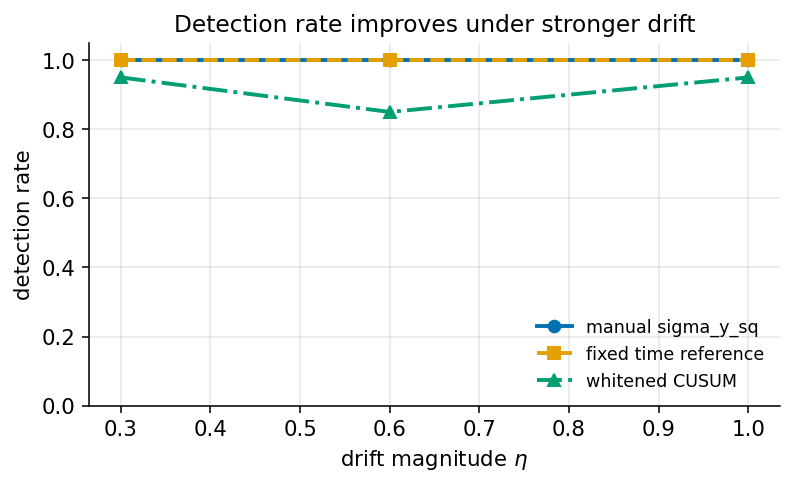

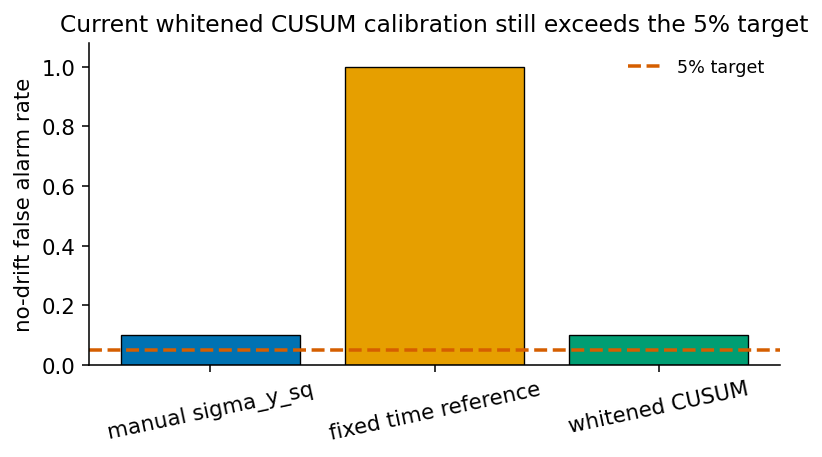

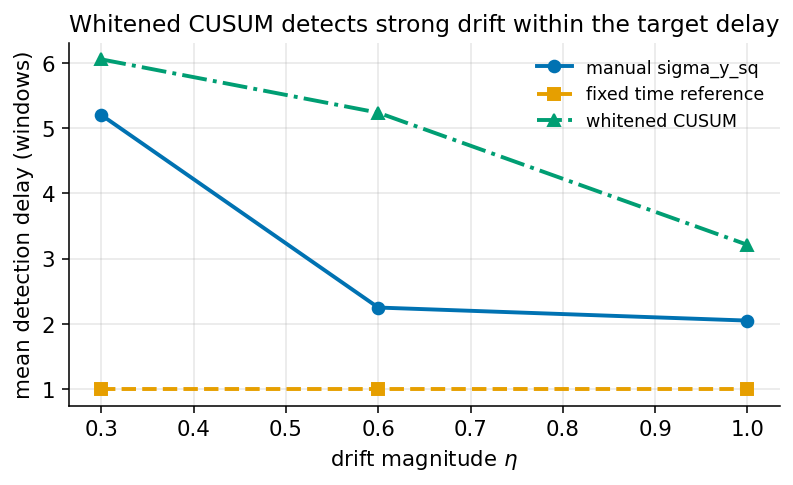

In [3]:
OKABE_ITO = {
    "sigma_y_sq": "#0072B2",      # blue
    "time_to_learn": "#E69F00",   # orange
    "whitened_cusum": "#009E73",  # green
}

LINE_STYLES = {
    "sigma_y_sq": ("o", "-"),
    "time_to_learn": ("s", "--"),
    "whitened_cusum": ("^", "-."),
}

DISPLAY_NAMES = {
    "sigma_y_sq": "manual sigma_y_sq",
    "time_to_learn": "fixed time reference",
    "whitened_cusum": "whitened CUSUM",
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_png(fig, stem: str) -> None:
    fig.savefig(NOTEBOOK_FIG_DIR / f"{stem}.png", bbox_inches="tight")


def plot_detection_rate(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    plot_df = df[(df["eta"] > 0) & df["detect_rate"].notna()]
    for trigger, group in plot_df.groupby("trigger"):
        group = group.sort_values("eta")
        marker, linestyle = LINE_STYLES[trigger]
        ax.plot(
            group["eta"],
            group["detect_rate"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6,
            color=OKABE_ITO[trigger],
            label=DISPLAY_NAMES[trigger],
        )
    ax.set_xlabel(r"drift magnitude $\eta$")
    ax.set_ylabel("detection rate")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="lower right")
    ax.set_title("Detection rate improves under stronger drift")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_detect_rate")
    return fig


def plot_false_alarm(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    null_df = df[df["eta"] == 0].copy().sort_values("trigger")
    colors = [OKABE_ITO[t] for t in null_df["trigger"]]
    labels = [DISPLAY_NAMES[t] for t in null_df["trigger"]]
    ax.bar(labels, null_df["false_alarm_rate"], color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(0.05, color="#D55E00", linestyle="--", linewidth=1.8, label="5% target")
    ax.set_ylabel("no-drift false alarm rate")
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis="x", rotation=12)
    ax.legend(frameon=False)
    ax.set_title("Current whitened CUSUM calibration still exceeds the 5% target")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_false_alarm")
    return fig


def plot_detection_delay(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    plot_df = df[(df["eta"] > 0) & df["mean_detection_delay"].notna()]
    for trigger, group in plot_df.groupby("trigger"):
        group = group.sort_values("eta")
        marker, linestyle = LINE_STYLES[trigger]
        ax.plot(
            group["eta"],
            group["mean_detection_delay"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6,
            color=OKABE_ITO[trigger],
            label=DISPLAY_NAMES[trigger],
        )
    ax.set_xlabel(r"drift magnitude $\eta$")
    ax.set_ylabel("mean detection delay (windows)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    ax.set_title("Whitened CUSUM detects strong drift within the target delay")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_delay")
    return fig


fig_detect = plot_detection_rate(summary)
fig_fa = plot_false_alarm(summary)
fig_delay = plot_detection_delay(summary)
plt.show()

### Detection rate across drift magnitude

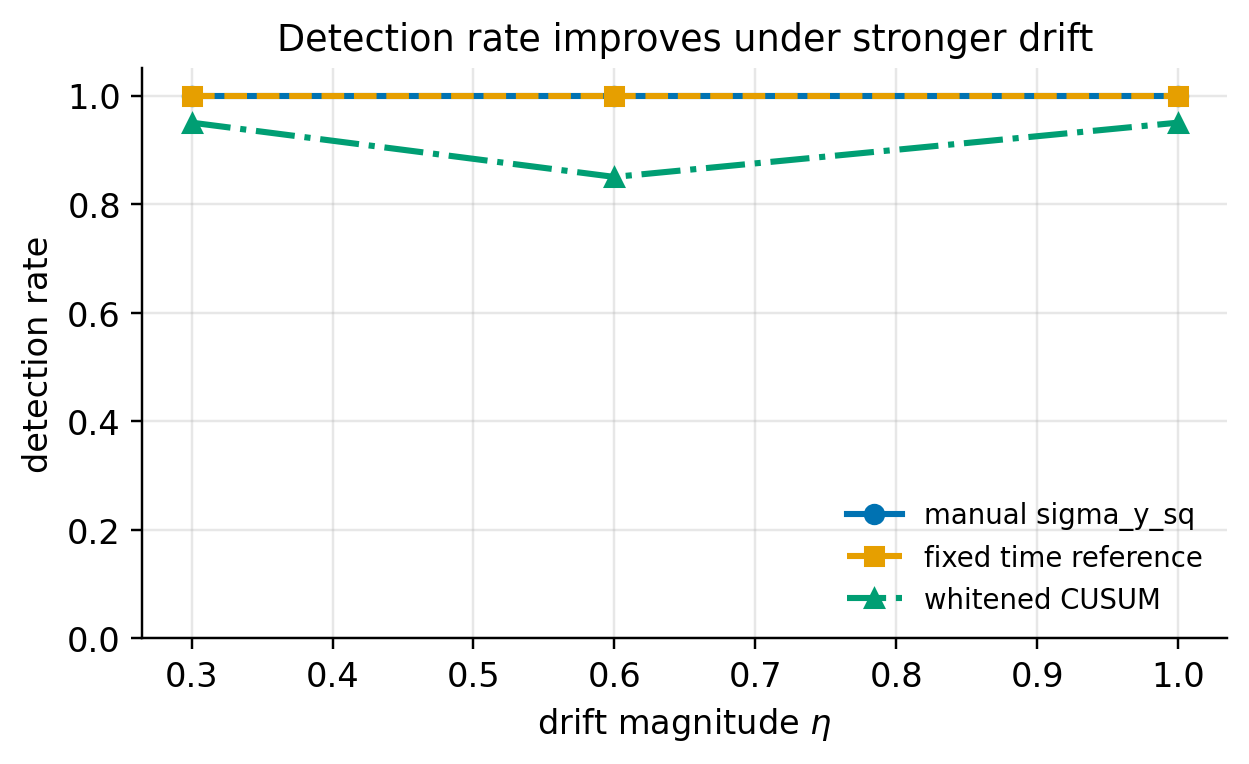

### No-drift false alarm with 5% target

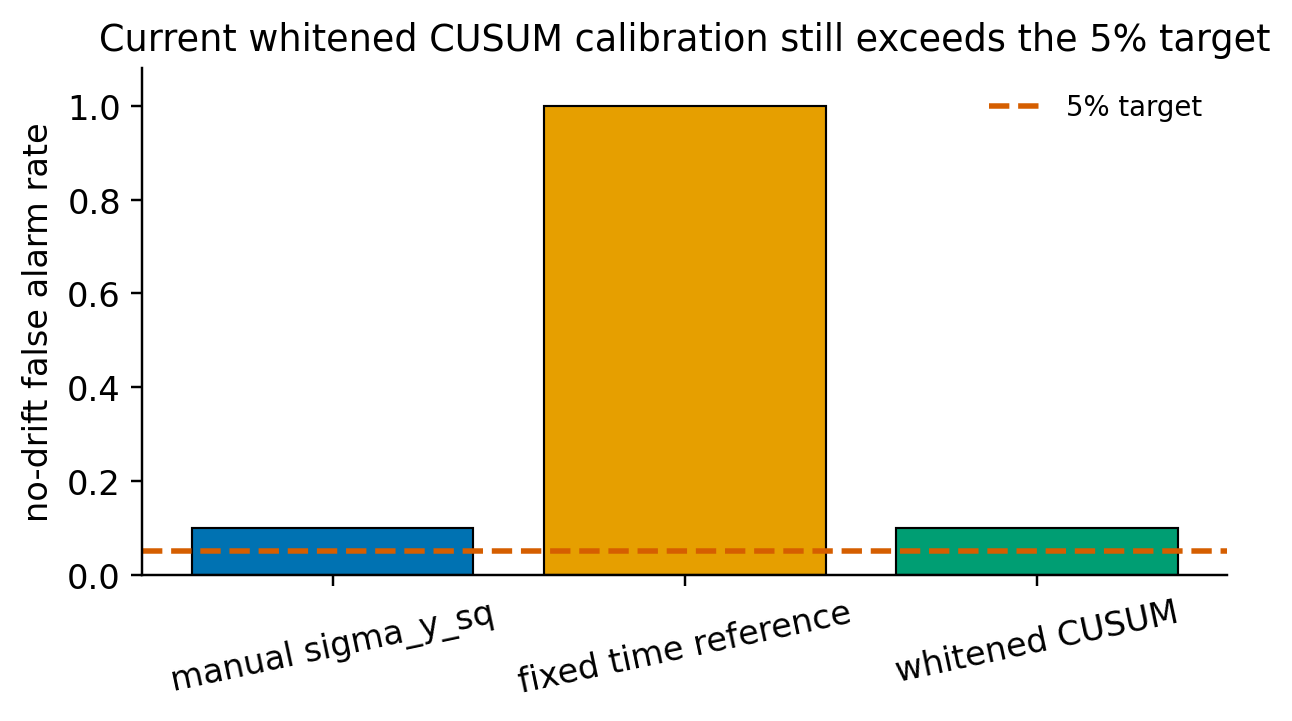

### Mean detection delay in windows

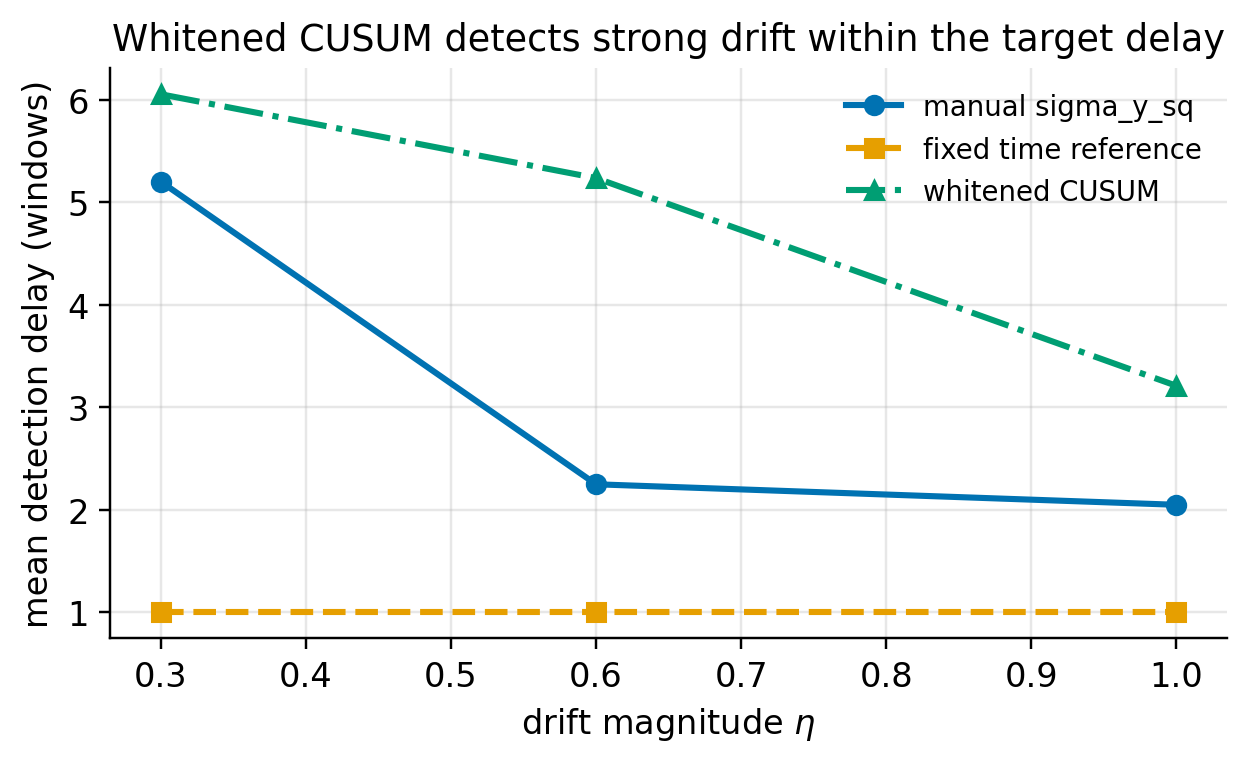

In [4]:
for fig_name, caption in [
    ("whitened_cusum_detect_rate.png", "Detection rate across drift magnitude"),
    ("whitened_cusum_false_alarm.png", "No-drift false alarm with 5% target"),
    ("whitened_cusum_delay.png", "Mean detection delay in windows"),
]:
    fig_path = NOTEBOOK_FIG_DIR / fig_name
    assert fig_path.exists(), fig_path
    display(Markdown(f"### {caption}"))
    display(Image(filename=str(fig_path)))

Figure captions for PPT:

1. **Detection rate.** Whitened CUSUM reaches 95% detection at `eta=1.0` and 85% at `eta=0.6`, showing that the trigger is effective under moderate-to-strong drift.
2. **False alarm.** The current calibration gives 2/20 no-drift false alarms, above the 5% target; this is the main remaining calibration issue.
3. **Detection delay.** Strong drift is detected within 3.21 windows on average, passing the <=5 window delay target.

## 6. What results did we get?

Validation setting:

| Item | Value |
| --- | --- |
| Checkpoint | `saved_SubspaceNet_trained_20260224_180720.pt` |
| N | 20 trajectories per cell |
| Whitened CUSUM calibration | `R_obs=0.125`, `p_fa=1e-6`, `b_offset=24` |

Key N=20 results:

| Case | Result |
| --- | --- |
| no drift | false alarm = 2/20 = 10%; target was <=1/20 = 5% |
| `eta=0.3` | detect rate = 19/20 = 95%; mean delay = 6.05 windows |
| `eta=0.6` | detect rate = 17/20 = 85%; mean delay = 5.24 windows |
| `eta=1.0` | detect rate = 19/20 = 95%; mean delay = 3.21 windows |

Acceptance gates:

| Gate | Target | Result | Status |
| --- | --- | --- | --- |
| strong drift detection | `eta=1.0`, >=18/20 | 19/20 | pass |
| medium drift detection | `eta=0.6`, >=12/20 | 17/20 | pass |
| weak drift | report only | 19/20 | pass |
| strong drift delay | <=5 windows | 3.21 windows | pass |
| no-drift false alarm | <=1/20 | 2/20 | fail |
| detect rate >= `sigma_y_sq` | same eta | lower at all drift levels | fail |

Overall: 4/6 gates passed.

**PPT takeaway.** Detection effectiveness is credible, but current calibration is not tight enough for a final paper-ready setting.

## 7. Compared with manual thresholding

The manual `sigma_y_sq` trigger and whitened CUSUM are useful in different ways.

| Dimension | Manual `sigma_y_sq > tau_sigma` | Whitened innovation CUSUM |
| --- | --- | --- |
| Statistic | Raw/sliding-window innovation energy | Covariance-normalized innovation statistic |
| Threshold meaning | Empirical/manual | Linked to false-alarm target through null-distribution framing |
| Transferability | Needs retuning across settings | More interpretable, but still needs calibration when model residuals are heavy-tailed |
| Current N=20 detection power | Strong: 100% at tested drift levels after retuning `tau_sigma=12` | Good but lower: 85-95% |
| Current no-drift false alarm | 2/20 after retuning | 2/20 with current calibration |
| Best current claim | Strong comparator baseline | Better statistical framing and calibration workflow |

Important interpretation:

- Do not claim whitened CUSUM currently detects earlier or more reliably than `sigma_y_sq`.
- Do claim that whitened CUSUM gives a cleaner statistical story: residuals are judged relative to EKF uncertainty, and the trigger has an explicit false-alarm-control framing.
- The current limitation is calibration: real SubspaceNet residuals are heavier-tailed than the ideal chi-square null, so `R_obs` and `b_offset` still need closed-loop tuning.

**PPT takeaway.** The benefit is interpretability and deployment-oriented calibration, not yet raw detection superiority.

## 8. Final slide message

### What we planned

Replace manual/fixed online-learning triggers with a whitened innovation CUSUM trigger that uses EKF uncertainty.

### How we did it

1. Extracted innovation statistics already available in the EKF pipeline.
2. Converted raw residuals into the whitened statistic `c_i = y_i^T S_i^{-1}y_i`.
3. Added a Page-CUSUM trigger with configurable `p_fa`, `b_offset`, and reset behavior.
4. Wired the trigger into the closed-loop SubspaceNet+EKF online-learning pipeline.
5. Validated three triggers over N=20 trajectories: `time_to_learn`, `sigma_y_sq`, and `whitened_cusum`.

### What we found

- Whitened CUSUM detects drift effectively: 95% at `eta=1.0`, 85% at `eta=0.6`, 95% at `eta=0.3`.
- Strong-drift delay passes the target: 3.21 windows.
- Current no-drift false alarm is too high: 2/20 = 10%, target <=5%.
- Retuned `sigma_y_sq` remains a strong detection-power baseline.

### Final framing

This is a promising statistically interpretable trigger and calibration workflow. It is not yet a final paper configuration until false alarm is reduced to <=1/20 or validated with larger N.